- Plan of action
    - will build simple qa system
        - Dataset
            - 100 question answer pair
                - RNN   ---> Questions ---> Answer

- What is RNN
    - A Recurrent Neural Network (RNN) is a type of neural networks designed for processing sequential data. Unlike traditional feed forward neural networks, which process input independently, RNNs maintain a memory of previous inputs by using  loops in their architecture.
    - This makes them well-suited for tasks where context and order matter, such as time series forecasting, speech recognition and text generation.
    - 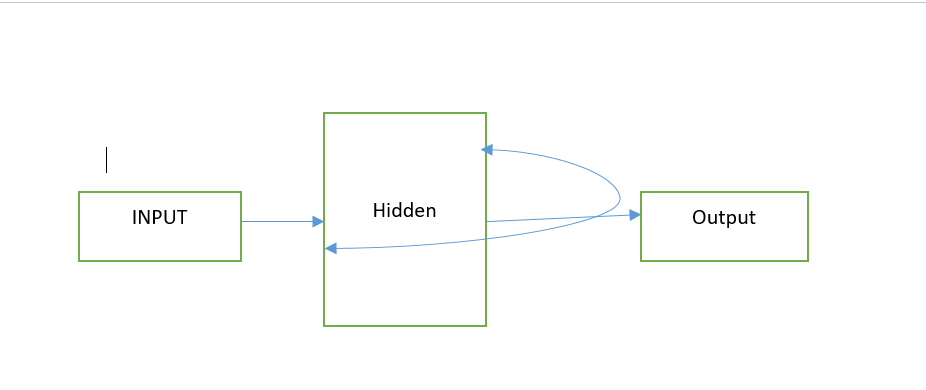

    - Example: How RNN Processes Text Data

        - Suppose we have the sentence:

            "I am Prajwal"

            - RNN processes the sentence word by word.

                - At time t = 1:
                    - Input: "I"
                    - Previous hidden state: h0 (initially zeros)
                    - RNN produces output o1 and hidden state h1.

                - At time t = 2:
                    - Input: "am"
                    - Previous hidden state: h1
                    - RNN produces output o2 and hidden state h2.

                - At time t = 3:
                    - Input: "Prajwal"
                    - Previous hidden state: h2
                    - RNN produces output o3 and hidden state h3.

            The hidden state acts as the memory of the network and carries information from previous words to future words.

            - Our RNN dont understand english so we have to convert these words into the numbers, and there are various ways one hot encoding, embedings.
                - In embeding we convert a word to a vector.
                - Suppose to our exmple we use embeding and dimension 2:
                    - I --> [1,2]
                    - am --> [3,4]
                    - Prajwal --> [5,6]
                Now RNN can easily process them...

                - Sample Visual Architecture:
                    - 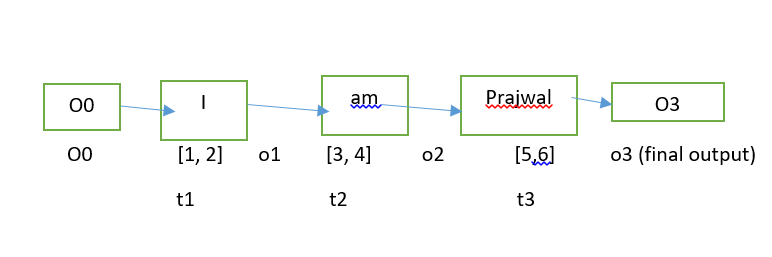
                    - in this image o0 is initial input which is set of random values.


In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device name is: {device}")

Device name is: cpu


In [61]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
df = pd.read_csv("/content/drive/MyDrive/DataSets/100_Unique_QA_Dataset.csv")
df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [63]:
# tokenize data (seprate each word)
def tokenize(text):
    text = text.lower()
    text = text.replace("?","")
    text = text.replace("'","")
    return text.split()

In [64]:
tokenize("What is capital of India?")

['what', 'is', 'capital', 'of', 'india']

In [65]:
# vocabaly forming (finding unique word and giving them indexes)
vocab = {'<UNK>':0}

In [66]:
def build_vocab(row):
    tokenized_question = tokenize(row["question"])
    tokenized_answer = tokenize(row["answer"])
    merge_tokens = tokenized_question + tokenized_answer
    for token in merge_tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

In [67]:
df.apply(build_vocab,axis=1)

,0
0,None
1,None
2,None
3,None
4,None
...,...
85,None
86,None
87,None
88,None


In [68]:
vocab

{'<UNK>': 0,
 'what': 1,
 'is': 2,
 'the': 3,
 'capital': 4,
 'of': 5,
 'france': 6,
 'paris': 7,
 'germany': 8,
 'berlin': 9,
 'who': 10,
 'wrote': 11,
 'to': 12,
 'kill': 13,
 'a': 14,
 'mockingbird': 15,
 'harper-lee': 16,
 'largest': 17,
 'planet': 18,
 'in': 19,
 'our': 20,
 'solar': 21,
 'system': 22,
 'jupiter': 23,
 'boiling': 24,
 'point': 25,
 'water': 26,
 'celsius': 27,
 '100': 28,
 'painted': 29,
 'mona': 30,
 'lisa': 31,
 'leonardo-da-vinci': 32,
 'square': 33,
 'root': 34,
 '64': 35,
 '8': 36,
 'chemical': 37,
 'symbol': 38,
 'for': 39,
 'gold': 40,
 'au': 41,
 'which': 42,
 'year': 43,
 'did': 44,
 'world': 45,
 'war': 46,
 'ii': 47,
 'end': 48,
 '1945': 49,
 'longest': 50,
 'river': 51,
 'nile': 52,
 'japan': 53,
 'tokyo': 54,
 'developed': 55,
 'theory': 56,
 'relativity': 57,
 'albert-einstein': 58,
 'freezing': 59,
 'fahrenheit': 60,
 '32': 61,
 'known': 62,
 'as': 63,
 'red': 64,
 'mars': 65,
 'author': 66,
 '1984': 67,
 'george-orwell': 68,
 'currency': 69,
 'unit

In [69]:
# covert word to numerical indeces
def text_to_indices(text,vocab):
    indexed_text = []
    for token in tokenize(text):
        if token in vocab:
           indexed_text.append(vocab[token])
        else:
            indexed_text.append(vocab["<UNK>"])
    return indexed_text

In [70]:
text_to_indices("Who is Prajwal?",vocab)

[10, 2, 0]

In [71]:
class QADataset(Dataset):

  def __init__(self, df, vocab):
    self.df = df
    self.vocab = vocab

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, index):

    numerical_question = text_to_indices(self.df.iloc[index]['question'], self.vocab)
    numerical_answer = text_to_indices(self.df.iloc[index]['answer'], self.vocab)

    return (
            torch.tensor(numerical_question), 
            torch.tensor(numerical_answer)
            )

In [72]:
dataset = QADataset(df,vocab)

In [76]:
dataset[4]

(tensor([ 1,  2,  3, 24, 25,  5, 26, 19, 27]), tensor([28]))

In [ ]:
dataloader = DataLoader(dataset,batch_size=1,shuffle=True)

In [78]:
for question, answer in dataloader:
    print(question,answer)

tensor([[ 42,  18,   2,   3, 281,  12,   3, 282]]) tensor([[205]])
tensor([[10, 55,  3, 56,  5, 57]]) tensor([[58]])
tensor([[ 78,  79, 195,  81,  19,   3, 196, 197, 198]]) tensor([[199]])
tensor([[ 78,  79, 129,  81,  19,   3,  21,  22]]) tensor([[36]])
tensor([[42, 18,  2, 62, 63,  3, 64, 18]]) tensor([[65]])
tensor([[42, 86, 87, 88, 89, 39, 90]]) tensor([[91]])
tensor([[ 10,  29, 130, 131]]) tensor([[132]])
tensor([[ 1,  2,  3, 17, 18, 19, 20, 21, 22]]) tensor([[23]])
tensor([[  1,   2,   3, 122, 123,  19,   3,  45]]) tensor([[124]])
tensor([[ 78,  79, 150, 151,  14, 152, 153]]) tensor([[154]])
tensor([[  1,   2,   3,   4,   5, 135]]) tensor([[136]])
tensor([[ 42, 125,   2,  62,  63,   3, 126, 127]]) tensor([[128]])
tensor([[ 42, 263, 264,  14, 265, 266, 158, 267]]) tensor([[268]])
tensor([[ 10, 140,   3, 141, 142,  12, 143,  83,   3, 144]]) tensor([[145]])
tensor([[  1,   2,   3,  69,   5, 155]]) tensor([[156]])
tensor([[ 1,  2,  3, 59, 25,  5, 26, 19, 60]]) tensor([[61]])
tensor([

In [91]:
class SimpleRNN(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.embeding = nn.Embedding(vocab_size,embedding_dim=50)
        self.rnn = nn.RNN(50,64,batch_first=True)
        self.fc = nn.Linear(64,vocab_size)
        
    def forward(self,question):
        embeded_question = self.embeding(question)
        hidden, final = self.rnn(embeded_question)
        output = self.fc(final.squeeze(0))
        return output

In [92]:
learning_rate = 0.001
epochs = 20

In [93]:
model = SimpleRNN(len(vocab))

In [94]:
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)

In [96]:
# training loop
for epoch in range(epochs):
    total_loss = 0
    for question, answer in dataloader:
        optimizer.zero_grad()
        # forward pass
        output = model(question)

        # loss
        loss = criteria(output,answer[0])

        # gradients
        loss.backward()

        # update
        optimizer.step()

        total_loss = total_loss + loss.item()

    print(f"Epoch: {epoch + 1}, Loss {total_loss:.4f}")

Epoch: 1, Loss 526.0206
Epoch: 2, Loss 456.5084
Epoch: 3, Loss 377.2125
Epoch: 4, Loss 317.3862
Epoch: 5, Loss 266.6292
Epoch: 6, Loss 217.5847
Epoch: 7, Loss 173.2013
Epoch: 8, Loss 134.8837
Epoch: 9, Loss 102.9670
Epoch: 10, Loss 78.8713
Epoch: 11, Loss 60.6483
Epoch: 12, Loss 47.5007
Epoch: 13, Loss 37.8143
Epoch: 14, Loss 30.4110
Epoch: 15, Loss 25.1683
Epoch: 16, Loss 20.9348
Epoch: 17, Loss 17.6600
Epoch: 18, Loss 14.9952
Epoch: 19, Loss 12.9461
Epoch: 20, Loss 11.1595


In [97]:
# predictions
def predict(model, question, threshold=0.5):

  # convert question to numbers
  numerical_question = text_to_indices(question, vocab)

  # tensor
  question_tensor = torch.tensor(numerical_question).unsqueeze(0)

  # send to model
  output = model(question_tensor)

  # convert logits to probs
  probs = torch.nn.functional.softmax(output, dim=1)

  # find index of max prob
  value, index = torch.max(probs, dim=1)

  if value < threshold:
    print("I don't know")

  print(list(vocab.keys())[index])

In [98]:
predict(model, "What is the largest planet in our solar system?")

jupiter
